 # Filtro pasa alto
 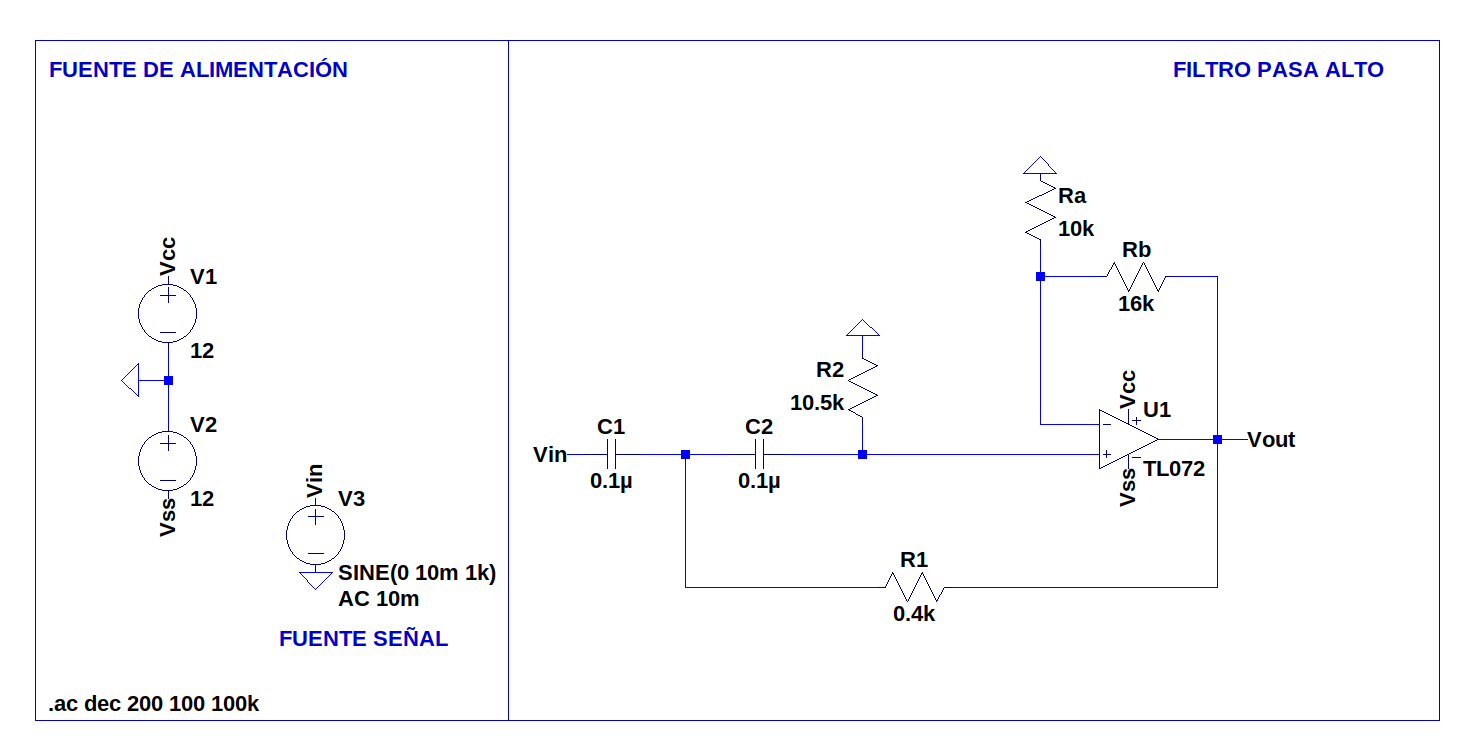

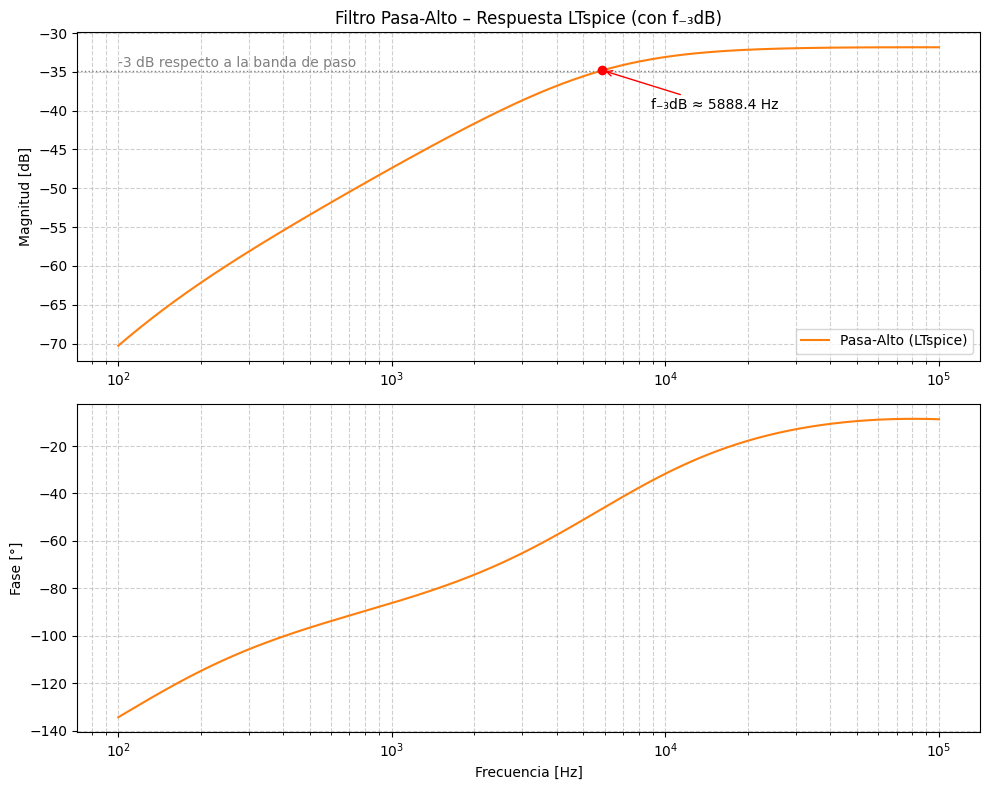

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20 * np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Bode PASA-ALTO con marcador de -3 dB (sin normalizar)
# ======================================================

filename = "filtro_pa.txt"   # <-- poné el nombre de tu txt acá

freq, mag_db, phase_deg = load_ltspice_complex(filename)

# Nivel máximo (banda de paso)
max_gain = np.max(mag_db)
target = max_gain - 3.0   # -3 dB respecto al máximo

# Para pasa-alto: buscamos el PRIMER punto que SUPERA ese nivel
idx_3db = np.where(mag_db >= target)[0][0]
f_3db = freq[idx_3db]
mag_3db = mag_db[idx_3db]

plt.figure(figsize=(10, 8))

# ---------------------------------------
# MAGNITUD
# ---------------------------------------
plt.subplot(2, 1, 1)
plt.semilogx(freq, mag_db, label="Pasa-Alto (LTspice)", color="tab:orange")

# Línea horizontal -3 dB
plt.axhline(target, color='gray', linestyle=':', linewidth=1)
plt.text(freq[0], target + 0.5,
         "-3 dB respecto a la banda de paso",
         color="gray")

# Punto f_-3dB
plt.semilogx(f_3db, mag_3db, 'ro')
plt.annotate(f"f₋₃dB ≈ {f_3db:.1f} Hz",
             xy=(f_3db, mag_3db),
             xytext=(1.5*f_3db, mag_3db - 5),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Pasa-Alto – Respuesta LTspice (con f₋₃dB)")
plt.legend()

# ---------------------------------------
# FASE
# ---------------------------------------
plt.subplot(2, 1, 2)
plt.semilogx(freq, phase_deg, color="tab:orange")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Fase [°]")
plt.xlabel("Frecuencia [Hz]")

plt.tight_layout()
plt.show()


Corridas encontradas:
   Step Information: C1val=90n  (Run: 1/3)
   Step Information: C1val=100n  (Run: 2/3)
   Step Information: C1val=110n  (Run: 3/3)
C1 = 0.9·C1_nom  -> fc ≈ 6531.3 Hz,  |H| ≈ -34.84 dB
C1 nominal      -> fc ≈ 5888.4 Hz, |H| ≈ -34.81 dB
C1 = 1.1·C1_nom -> fc ≈ 5308.8 Hz, |H| ≈ -34.82 dB


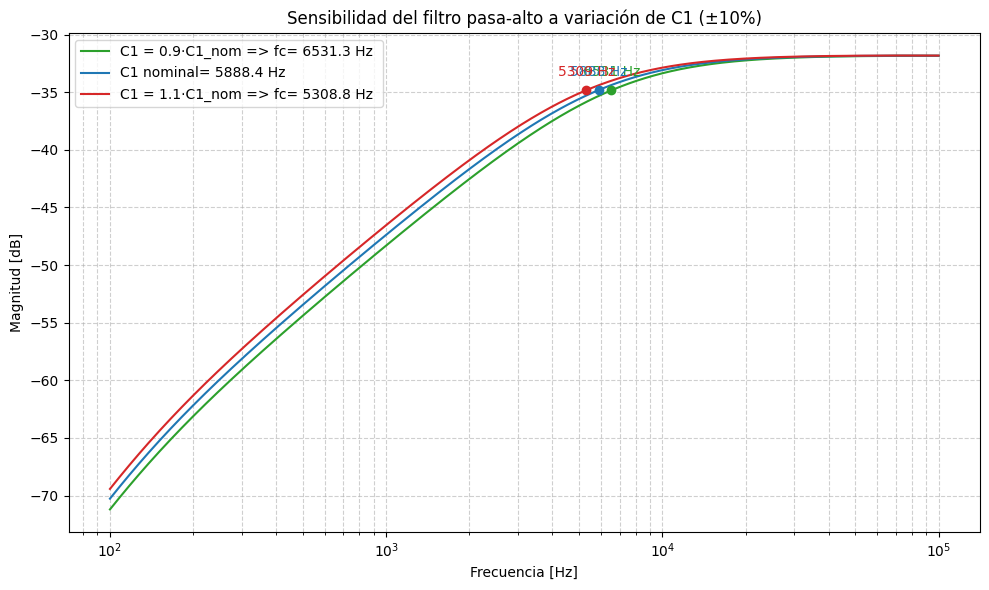

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def load_ltspice_step_runs(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    idx = 1  # saltar "Freq.   V(vout)"
    freq = None
    mags_db = []
    step_info = []

    while idx < len(lines):
        line = lines[idx].strip()

        if line.startswith("Step Information"):
            info = line
            step_info.append(info)
            idx += 1

            freq_run = []
            re_run = []
            im_run = []

            while idx < len(lines):
                l = lines[idx].strip()
                if not l:
                    idx += 1
                    continue
                if l.startswith("Step Information"):
                    break

                parts = l.split()
                if len(parts) < 2:
                    idx += 1
                    continue

                f_val = float(parts[0])
                re_str, im_str = parts[1].split(',')
                re_val = float(re_str)
                im_val = float(im_str)

                freq_run.append(f_val)
                re_run.append(re_val)
                im_run.append(im_val)

                idx += 1

            freq_run = np.array(freq_run)
            v_c = np.array(re_run) + 1j*np.array(im_run)
            mag_db_run = 20*np.log10(np.abs(v_c))

            if freq is None:
                freq = freq_run

            mags_db.append(mag_db_run)
        else:
            idx += 1

    return freq, mags_db, step_info


def cutoff_point(freq, mag_db, delta_db=3):
    """
    Devuelve (f_c, mag_c) donde la magnitud está a delta_db dB
    por debajo del máximo de la curva.
    """
    mag_max = np.max(mag_db)
    target = mag_max - delta_db
    idx = np.argmin(np.abs(mag_db - target))
    return freq[idx], mag_db[idx]


# =======================
#  USO PARA C1 (HP)
# =======================

filename = "filtro_pa_c1val.txt"   # tu archivo exportado

freq, mags_db, step_info = load_ltspice_step_runs(filename)
print("Corridas encontradas:")
for s in step_info:
    print("  ", s)

mag_90n, mag_100n, mag_110n = mags_db  # asumiendo orden 90n,100n,110n

# Frecuencias de corte (-3 dB respecto al máximo de cada curva)
fc_90, mc_90   = cutoff_point(freq, mag_90n)
fc_100, mc_100 = cutoff_point(freq, mag_100n)
fc_110, mc_110 = cutoff_point(freq, mag_110n)

print(f"C1 = 0.9·C1_nom  -> fc ≈ {fc_90:.1f} Hz,  |H| ≈ {mc_90:.2f} dB")
print(f"C1 nominal      -> fc ≈ {fc_100:.1f} Hz, |H| ≈ {mc_100:.2f} dB")
print(f"C1 = 1.1·C1_nom -> fc ≈ {fc_110:.1f} Hz, |H| ≈ {mc_110:.2f} dB")

plt.figure(figsize=(10,6))

# Curvas
plt.semilogx(freq, mag_90n,  label=f"C1 = 0.9·C1_nom => fc= {fc_90:.1f} Hz ", color="tab:green")
plt.semilogx(freq, mag_100n, label=f"C1 nominal= {fc_100:.1f} Hz",      color="tab:blue")
plt.semilogx(freq, mag_110n, label=f"C1 = 1.1·C1_nom => fc= {fc_110:.1f} Hz", color="tab:red")

# Marcadores de -3 dB
plt.semilogx(fc_90,  mc_90,  'o', color="tab:green")
plt.semilogx(fc_100, mc_100, 'o', color="tab:blue")
plt.semilogx(fc_110, mc_110, 'o', color="tab:red")

# Opcional: anotaciones
plt.annotate(f"{fc_90:.0f} Hz",  (fc_90,  mc_90),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:green")
plt.annotate(f"{fc_100:.0f} Hz", (fc_100, mc_100),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:blue")
plt.annotate(f"{fc_110:.0f} Hz", (fc_110, mc_110),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:red")

plt.grid(which="both", ls='--', alpha=0.6)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Sensibilidad del filtro pasa-alto a variación de C1 (±10%)")
plt.legend()
plt.tight_layout()
plt.show()
